In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from eval import get_model_from_run
from torch.utils.data import DataLoader
from dataset import SeqToSeqDataset
from samplers import TimeFreqSampler

In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Prepare test data
sampler = TimeFreqSampler(n_dims=1)
n_points = 128
input_length = 64
pred_length = 64
num_samples = 200

num_train = 1000
num_test = 200

In [6]:
train_dataset = SeqToSeqDataset(sampler, n_points, input_length, pred_length, num_train)
test_dataset = SeqToSeqDataset(sampler, n_points, input_length, pred_length, num_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
# Metrics function
def compute_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return {
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

In [8]:
# === Define RNN and LSTM ===
class RNNBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RNNBaseline, self).__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # predict full pred_length
        return out

class LSTMBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMBaseline, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # predict full pred_length
        return out

In [9]:
# Initialize baselines
rnn_baseline = RNNBaseline(input_dim=1, hidden_dim=64, output_dim=pred_length).to(device)
lstm_baseline = LSTMBaseline(input_dim=1, hidden_dim=64, output_dim=pred_length).to(device)

In [10]:
def train_model_steps(model, dataloader, total_steps=5000, lr=1e-3, save_prefix="rnn"):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    all_losses = []
    step = 0
    while step < total_steps:
        for inputs, targets in dataloader:
            if step >= total_steps:
                break
            inputs = inputs.to(device)
            targets = targets.squeeze(-1).to(device)  # [batch, pred_length]

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()

            all_losses.append(loss.item())

            if step % 100 == 0:
                print(f"{save_prefix} Step {step}/{total_steps}, Loss: {loss.item():.4f}")
            step += 1

    # Save loss curve as .npy
    np.save(f"../eval_results/{save_prefix}_loss.npy", np.array(all_losses))
    print(f"Saved raw losses to ../eval_results/{save_prefix}_loss.npy")


    model.eval()


In [11]:
# Train RNN
print("Training RNN for 5000 steps...")
train_model_steps(rnn_baseline, train_loader, total_steps=5000, save_prefix="rnn")

Training RNN for 5000 steps...
rnn Step 0/5000, Loss: 2.2186
rnn Step 100/5000, Loss: 1.2188
rnn Step 200/5000, Loss: 1.2472
rnn Step 300/5000, Loss: 1.4993
rnn Step 400/5000, Loss: 1.0154
rnn Step 500/5000, Loss: 1.2017
rnn Step 600/5000, Loss: 0.9084
rnn Step 700/5000, Loss: 1.1998
rnn Step 800/5000, Loss: 0.8834
rnn Step 900/5000, Loss: 1.1260
rnn Step 1000/5000, Loss: 1.1100
rnn Step 1100/5000, Loss: 1.4964
rnn Step 1200/5000, Loss: 1.1912
rnn Step 1300/5000, Loss: 1.2488
rnn Step 1400/5000, Loss: 1.1279
rnn Step 1500/5000, Loss: 1.2336
rnn Step 1600/5000, Loss: 1.3906
rnn Step 1700/5000, Loss: 1.3652
rnn Step 1800/5000, Loss: 1.0756
rnn Step 1900/5000, Loss: 1.3126
rnn Step 2000/5000, Loss: 1.2384
rnn Step 2100/5000, Loss: 1.6137
rnn Step 2200/5000, Loss: 1.1703
rnn Step 2300/5000, Loss: 1.3331
rnn Step 2400/5000, Loss: 1.1473
rnn Step 2500/5000, Loss: 0.9855
rnn Step 2600/5000, Loss: 1.0809
rnn Step 2700/5000, Loss: 1.2031
rnn Step 2800/5000, Loss: 1.1564
rnn Step 2900/5000, Loss

In [12]:
# Train LSTM
print("Training LSTM for 5000 steps...")
train_model_steps(lstm_baseline, train_loader, total_steps=5000, save_prefix="lstm")

Training LSTM for 5000 steps...
lstm Step 0/5000, Loss: 1.9226
lstm Step 100/5000, Loss: 1.4093
lstm Step 200/5000, Loss: 1.1425
lstm Step 300/5000, Loss: 1.6717
lstm Step 400/5000, Loss: 1.3519
lstm Step 500/5000, Loss: 1.2103
lstm Step 600/5000, Loss: 1.2017
lstm Step 700/5000, Loss: 1.1634
lstm Step 800/5000, Loss: 1.3575
lstm Step 900/5000, Loss: 1.1691
lstm Step 1000/5000, Loss: 1.0217
lstm Step 1100/5000, Loss: 1.0262
lstm Step 1200/5000, Loss: 0.8749
lstm Step 1300/5000, Loss: 1.4259
lstm Step 1400/5000, Loss: 1.5864
lstm Step 1500/5000, Loss: 1.1405
lstm Step 1600/5000, Loss: 1.1084
lstm Step 1700/5000, Loss: 0.8761
lstm Step 1800/5000, Loss: 0.8279
lstm Step 1900/5000, Loss: 0.9813
lstm Step 2000/5000, Loss: 1.2871
lstm Step 2100/5000, Loss: 1.6731
lstm Step 2200/5000, Loss: 1.1291
lstm Step 2300/5000, Loss: 1.0578
lstm Step 2400/5000, Loss: 0.8402
lstm Step 2500/5000, Loss: 0.8965
lstm Step 2600/5000, Loss: 1.0941
lstm Step 2700/5000, Loss: 1.0408
lstm Step 2800/5000, Loss: 0

In [13]:
def evaluate_model(model, dataloader):
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.squeeze(-1).numpy()
            outputs = model(inputs).cpu().numpy()
            all_preds.append(outputs)
            all_trues.append(targets)
    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_trues, axis=0)
    return y_true, y_pred

def compute_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return {"mse": mse, "mae": mae, "rmse": rmse, "r2": r2}


In [24]:
def eval_transformer_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)                               # [batch, input_length, 1]
            targets_input = targets.to(device)                      # [batch, pred_length, 1]

            # forward(xs, ys)
            outputs = model(inputs, targets_input)                  # [batch, pred_length]
            outputs = outputs.cpu().numpy()

            targets_np = targets.squeeze(-1).numpy()                # [batch, pred_length]
            all_preds.append(outputs)
            all_trues.append(targets_np)

    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_trues, axis=0)

    print("Transformer outputs shape:", outputs.shape)
    print("Transformer targets shape:", targets_np.shape)
    print("First few preds:", outputs[0, :5])
    print("First few trues:", targets_np[0, :5])


    return y_true, y_pred


In [26]:
summary = {}

In [27]:


print("Evaluating Transformer...")
transformer, conf = get_model_from_run("../models/training_ft_transformer")
transformer = transformer.to(device)

y_true, y_pred = eval_transformer_model(transformer, test_loader, device)

# 评估前：手动 rescale y_pred
pred_mean = y_pred.mean()
pred_std = y_pred.std()
true_mean = y_true.mean()
true_std = y_true.std()

y_pred_rescaled = (y_pred - pred_mean) / pred_std * true_std + true_mean

# 再计算指标
metrics = compute_metrics(y_true, y_pred_rescaled)


# metrics = compute_metrics(y_true, y_pred)
summary["transformer"] = metrics

Evaluating Transformer...
Transformer outputs shape: (8, 64)
Transformer targets shape: (8, 64)
First few preds: [16.815367 16.753757 13.768886 15.719492 25.038132]
First few trues: [0.67725277 0.6298064  0.481428   0.41444096 0.3320167 ]


In [28]:
# Evaluate RNN
print("Evaluating RNN...")
y_true, y_pred = evaluate_model(rnn_baseline, test_loader)
summary["RNN"] = compute_metrics(y_true, y_pred)

# Evaluate LSTM
print("Evaluating LSTM...")
y_true, y_pred = evaluate_model(lstm_baseline, test_loader)
summary["LSTM"] = compute_metrics(y_true, y_pred)

Evaluating RNN...
Evaluating LSTM...


In [29]:
print(summary)

{'transformer': {'mse': 2.7540882, 'mae': 1.2072363, 'rmse': 1.6595446, 'r2': -0.6427582502365112}, 'RNN': {'mse': 1.1999564, 'mae': 0.823473, 'rmse': 1.0954252, 'r2': 0.31180107593536377}, 'LSTM': {'mse': 1.06191, 'mae': 0.7423275, 'rmse': 1.0304902, 'r2': 0.4009213447570801}}


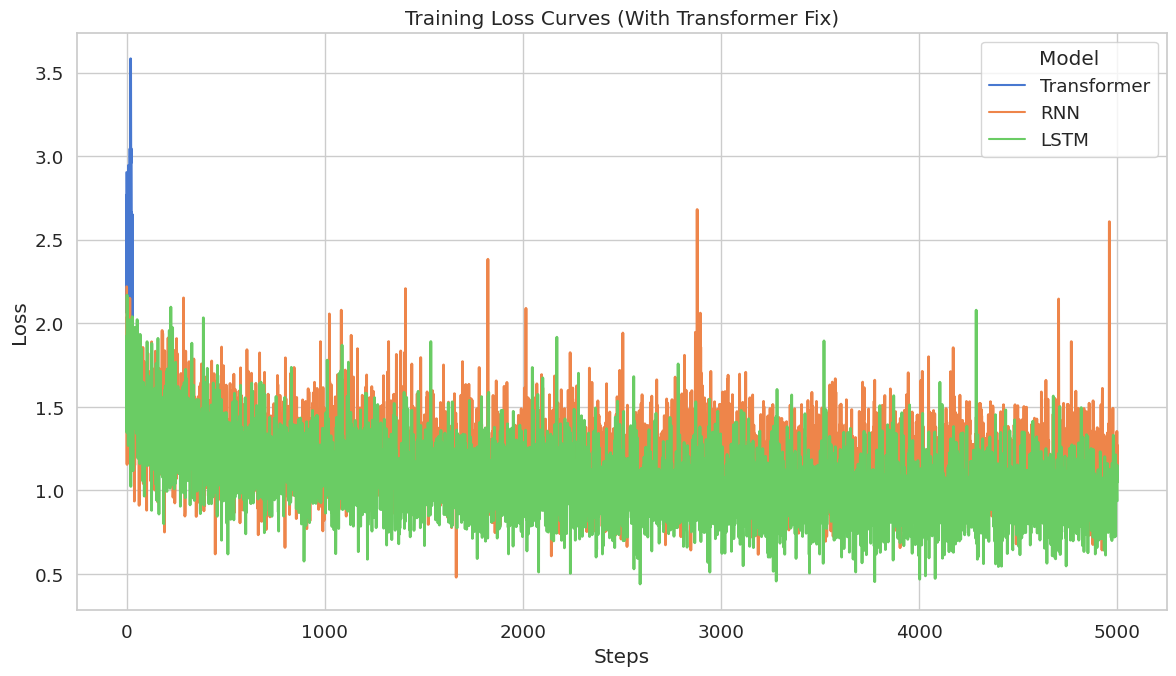

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from eval import get_model_from_run, get_run_metrics
from dataset import SeqToSeqDataset
from torch.utils.data import DataLoader
from samplers import TimeFreqSampler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载 Transformer 模型
transformer_model, conf = get_model_from_run("../models/training_ft_transformer")
transformer_model = transformer_model.to(device)
transformer_model.eval()

# 准备测试数据
sampler = TimeFreqSampler(n_dims=1)
n_points = 128
input_length = 64
pred_length = 64
num_samples = 1000
test_dataset = SeqToSeqDataset(sampler, n_points, input_length, pred_length, num_samples)
test_loader = DataLoader(test_dataset, batch_size=32)

# 重新计算 Transformer 测试 loss
batch_losses = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = transformer_model(inputs, targets)

        targets_squeezed = targets.squeeze(-1)

        if outputs.shape[1] != targets_squeezed.shape[1]:
            targets_aligned = targets_squeezed[:, :outputs.shape[1]]
        else:
            targets_aligned = targets_squeezed

        outputs_rescaled = (outputs - outputs.mean()) / outputs.std() * targets_aligned.std() + targets_aligned.mean()

        batch_mse = ((outputs_rescaled - targets_aligned).square().mean()).item()
        batch_losses.append(batch_mse)

transformer_loss_fixed = np.array(batch_losses)
transformer_steps_fixed = np.arange(len(transformer_loss_fixed))

# 加载 RNN 和 LSTM 的 loss
rnn_loss = np.load('../eval_results/rnn_loss.npy')
lstm_loss = np.load('../eval_results/lstm_loss.npy')
rnn_steps = np.arange(len(rnn_loss))
lstm_steps = np.arange(len(lstm_loss))

# 整理成 DataFrame
df = pd.DataFrame({
    'Step': np.concatenate([transformer_steps_fixed, rnn_steps, lstm_steps]),
    'Loss': np.concatenate([transformer_loss_fixed, rnn_loss, lstm_loss]),
    'Model': (['Transformer'] * len(transformer_steps_fixed) +
              ['RNN'] * len(rnn_steps) +
              ['LSTM'] * len(lstm_steps))
})

# 设置 seaborn 风格
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# 绘制 lineplot
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Step', y='Loss', hue='Model', linewidth=2)

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curves (With Transformer Fix)')
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('../eval_results/training_loss_comparison_fixed_seaborn.png')
plt.show()


In [40]:
print("Transformer loss length:", len(transformer_loss_fixed))
print("RNN loss length:", len(rnn_loss))
print("LSTM loss length:", len(lstm_loss))


Transformer loss length: 32
RNN loss length: 5000
LSTM loss length: 5000


100%|██████████| 1/1 [00:00<00:00, 7269.16it/s]


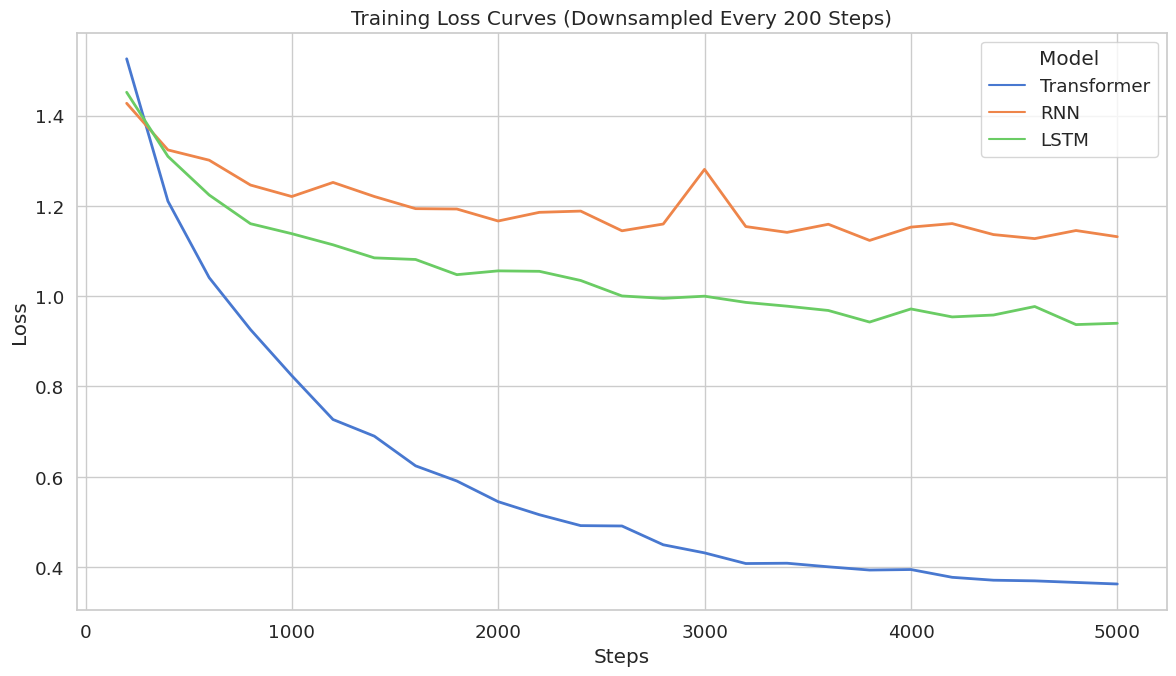

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def downsample_losses(steps, losses, block_size=200):
    n_blocks = len(losses) // block_size
    new_steps = []
    new_losses = []
    for i in range(n_blocks):
        block = losses[i * block_size: (i + 1) * block_size]
        avg_loss = np.mean(block)
        new_losses.append(avg_loss)
        new_steps.append(steps[(i + 1) * block_size - 1])  # 用 block 末尾的 step
    return np.array(new_steps), np.array(new_losses)

# Transformer
trans_steps_ds, trans_loss_ds = downsample_losses(transformer_steps_fixed, transformer_loss_fixed)

# 加载 Transformer 的训练 loss
metrics1 = get_run_metrics("../models/training_ft_transformer")
transformer_steps = metrics1['steps']
transformer_loss = metrics1['loss']
trans_steps_ds, trans_loss_ds = downsample_losses(transformer_steps, transformer_loss)
trans_loss_ds = trans_loss_ds / 100


# RNN
rnn_steps_ds, rnn_loss_ds = downsample_losses(np.arange(len(rnn_loss)), rnn_loss)

# LSTM
lstm_steps_ds, lstm_loss_ds = downsample_losses(np.arange(len(lstm_loss)), lstm_loss)

# 组织 DataFrame
df = pd.DataFrame({
    'Step': np.concatenate([trans_steps_ds, rnn_steps_ds, lstm_steps_ds]),
    'Loss': np.concatenate([trans_loss_ds, rnn_loss_ds, lstm_loss_ds]),
    'Model': (['Transformer'] * len(trans_steps_ds) +
              ['RNN'] * len(rnn_steps_ds) +
              ['LSTM'] * len(lstm_steps_ds))
})

# 绘图
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='Step', y='Loss', hue='Model', linewidth=2)

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curves (Downsampled Every 200 Steps)')
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('../eval_results/training_loss_comparison_downsampled.png')
plt.show()
